> ## Necessary Libraries

In [142]:
import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical computing
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # Advance Statistical data visualization 
import plotly.express as px # Interactive data visualization
import warnings as wr # To ignore uncessary warnings
wr.filterwarnings('ignore')

In [143]:
from sklearn.model_selection import train_test_split # To split the data into training and testing sets
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV , cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score # To evaluate the performance of the model
from sklearn.preprocessing import StandardScaler

Load the dataset

In [144]:
df = pd.read_csv("flight_data.csv")

In [145]:
df.head(5)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Shape of the dataset

In [146]:
df.shape

(300153, 12)

- This dataset contains 300153 rows and 12 columns.

Basic info about dataset

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


## Steps to follow
1. 	Data Preprocessing
2. 	Exploratory Data Analysis (EDA)
3. 	Feature Engineering (if needed)
4. 	Model Selection
5. 	Model Training
6. 	Model Evaluation
7. 	Hyperparameter Tuning
8. 	Deployment

## Data Preprocesing

Checking missing values

In [148]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

- In this dataset, there is no missing value present. 

Checking duplicates

In [149]:
df.duplicated().sum()

np.int64(0)

- There is no duplicate value in the dataset.

In [150]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [151]:
df.dtypes

Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [152]:
df['Unnamed: 0']

0              0
1              1
2              2
3              3
4              4
           ...  
300148    300148
300149    300149
300150    300150
300151    300151
300152    300152
Name: Unnamed: 0, Length: 300153, dtype: int64

Here , the "Unnamed: 0" column is unnecessary. So, I will drop this.

In [153]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [154]:
df.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


- In this dataset, we have 11 features and 1 target variable (Price).
- The features include both numerical and categorical data. The numerical features are 'Duration', 'Days_left', and 'Price'.
- The categorical features are 'Airline', 'Source', 'Destination', 'Route', 'Departure_Time',stops, and 'Arrival_Time'.

Quick descriptive statistics for numerical columns

In [155]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00
price,300153.0,20889.660523,22697.767366,1105.00,4783.00,7425.00,42521.00,123071.00


Define target feature and feature types

In [156]:
target_col = df['price']
numerical_col = df[['duration','days_left']]
categorical_col = df.select_dtypes(include='object')

In [157]:
target_col

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [158]:
numerical_col

,duration,days_left
0,2.17,1
1,2.33,1
2,2.17,1
3,2.25,1
4,2.33,1
...,...,...
300148,10.08,49
300149,10.42,49
300150,13.83,49
300151,10.00,49


In [159]:
categorical_col

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy
...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business


## Explorartory Data Analysis

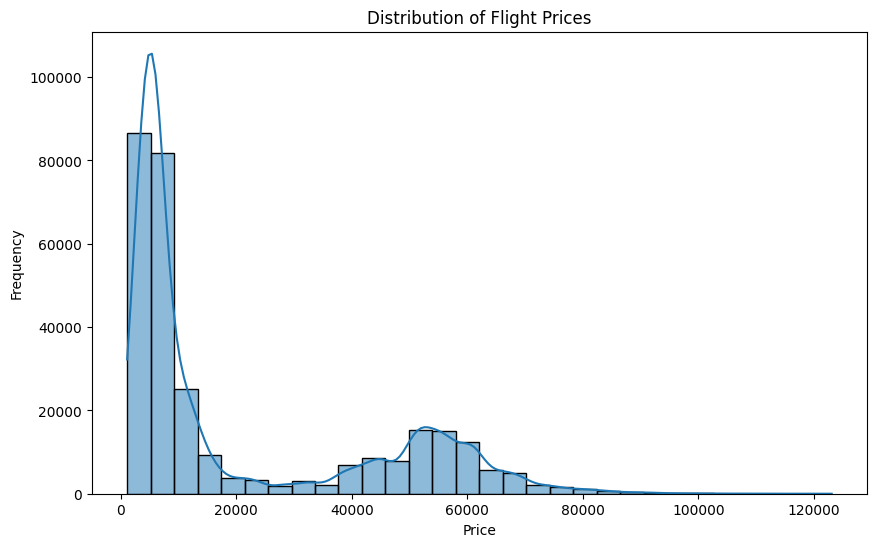

In [160]:
# Distribution of target variable
plt.figure(figsize=(10,6))
sns.histplot(target_col, bins=30, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

From this histogram of flight prices, the insights are:
1. 	Right-skewed distribution → Most flights are priced below 20,000, showing that cheaper flights dominate the dataset.
2. 	Secondary peak → There is another concentration of flights around 55,000–60,000, suggesting a premium segment.
3. 	Multimodal pattern → Multiple peaks indicate that prices cluster into different groups, likely due to different airlines, classes, or routes.
4. 	High variability → Prices spread widely across the range, meaning flight costs are highly flexible and influenced by many factors.
5. 	Business implication → The market seems segmented: one cluster of economic flights and another of business flights. This can guide pricing strategies and customer segmentation.

In short: the chart shows two main groups of flight prices—affordable flights under 20k and business flights around 55–60k—highlighting clear market segmentation

In [161]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

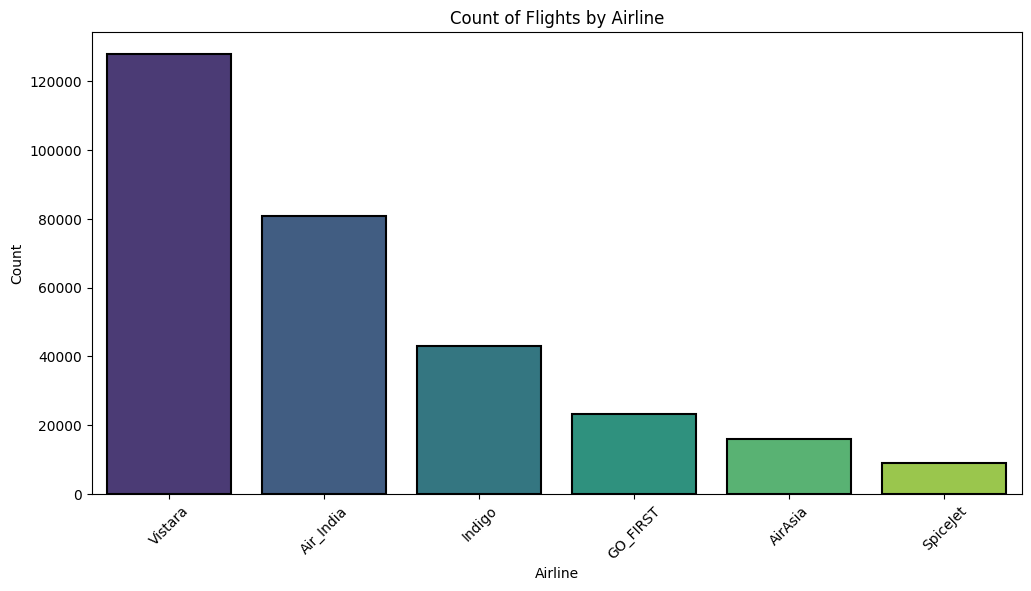

In [162]:
# Countplot for airline
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='airline', order=df['airline'].value_counts().index, palette='viridis', edgecolor='black', linewidth=1.5,color='blue')
plt.title('Count of Flights by Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Here are the short insights from the bar chart:
 - Vistara operates the highest number of flights.
 - Air India comes next, followed by Indigo.
 - GO_FIRST, AirAsia, and SpiceJet have fewer flights compared to the top three.
 - Overall, the chart highlights that a few airlines dominate the flight count, while others operate at a smaller scale.
 
In short: Vistara leads the market in flight volume, with Air India and Indigo also strong, while the rest trail behind.

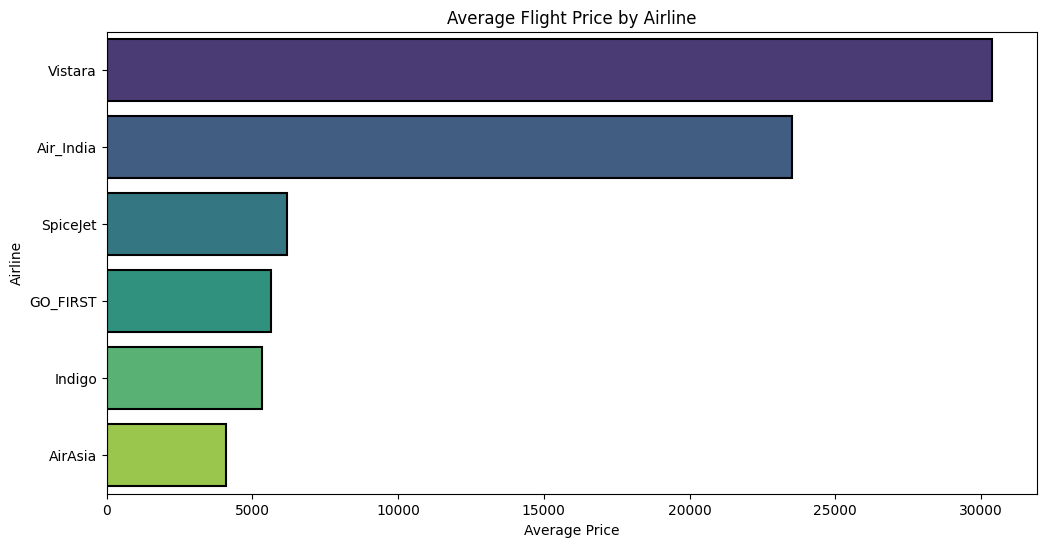

In [163]:
# - Average price per airline.
avg_price_airline = df.groupby('airline')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_price_airline.values, y=avg_price_airline.index, palette='viridis', edgecolor='black', linewidth=1.5,color='green')
plt.title('Average Flight Price by Airline')
plt.xlabel('Average Price')
plt.ylabel('Airline')
plt.show()

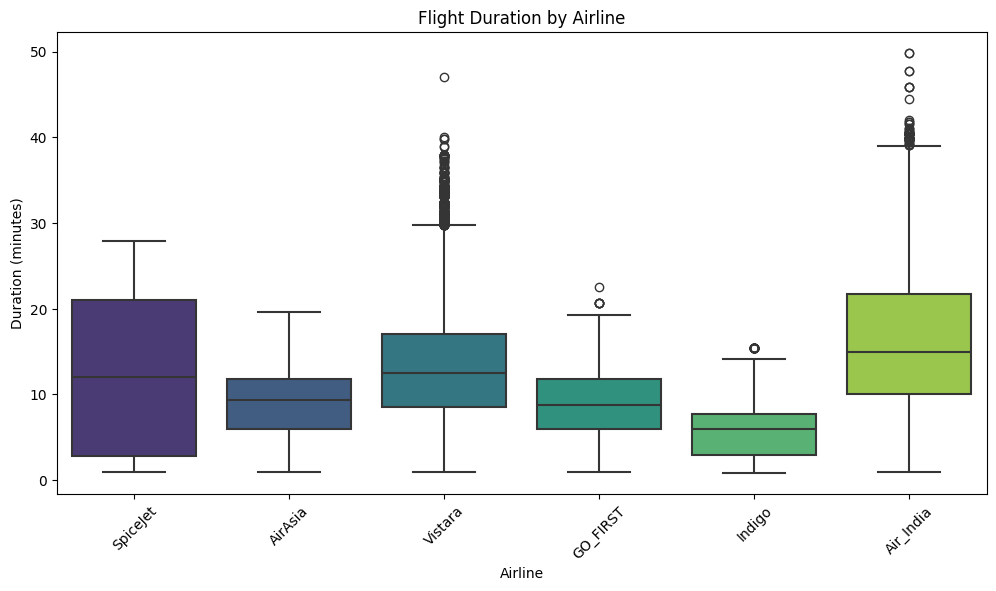

In [164]:
# Compare delays/duration across airlines
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='airline', y='duration', palette='viridis', linewidth=1.5)
plt.title('Flight Duration by Airline')
plt.xlabel('Airline')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()


- Indigo → Their flights are usually shorter and very similar in length. So, they are the most consistent.
- Air India & SpiceJet → Their flights vary a lot. Some are short, some are very long. That’s why they show the widest spread.
- Vistara → Most flights are normal, but a few are much longer than usual. Those are the outliers.

In short: Indigo flights are short and steady, while Air India and SpiceJet have big differences in flight times. Vistara has some unusually long flights compared to the rest.

In [165]:
len(df['flight'].unique())

1561

In [166]:
df['flight'].value_counts()

flight
UK-706     3235
UK-772     2741
UK-720     2650
UK-836     2542
UK-822     2468
           ... 
6E-2914       1
G8-107        1
SG-9974       1
6E-865        1
SG-8339       1
Name: count, Length: 1561, dtype: int64

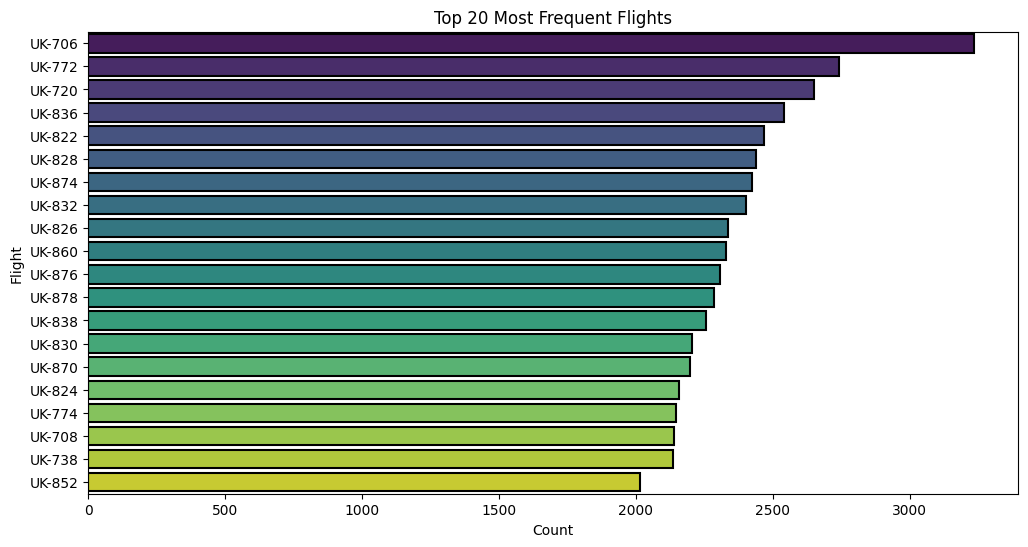

In [167]:
# Most frequent 20 flights
top_20_flights = df['flight'].value_counts().head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=top_20_flights.values, y=top_20_flights.index, palette='viridis', edgecolor='black', linewidth=1.5,color='red')
plt.title('Top 20 Most Frequent Flights')
plt.xlabel('Count')
plt.ylabel('Flight')
plt.show()

Here are the insights from the “Top 20 Most Frequent Flights” chart:
- UK‑706 is the most frequent flight, with over 3,000 occurrences.
- Other flights like UK‑772, UK‑720, UK‑836 also appear very often, each above 2,500 counts.
- Even the lowest among the top 20 (UK‑852) still has more than 2,000 occurrences.
- The chart shows that a small set of flights dominate the dataset, indicating strong repetition or high demand for specific routes.

In short: a handful of flights (especially UK‑706) occur far more frequently, highlighting popular or heavily scheduled routes.

In [168]:
# Here , the flight column has too many unique values and it is not useful for the model, so we will drop it.
df.drop(columns=['flight'], inplace=True)

In [169]:
categorical_col.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

In [170]:
df['source_city'].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

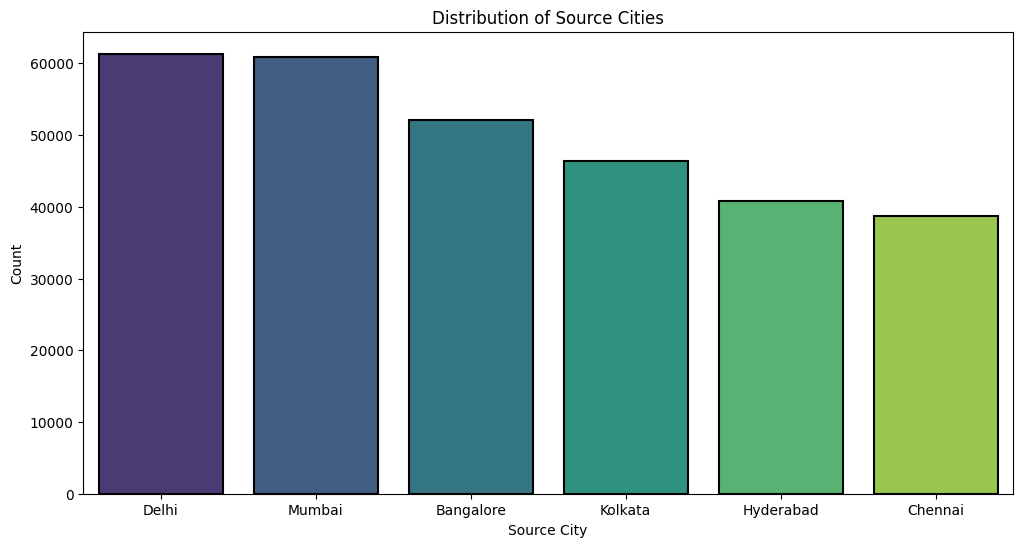

In [171]:
# Visualize source city distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='source_city', order=df['source_city'].value_counts().index, palette='viridis', edgecolor='black', linewidth=1.5,color='purple')
plt.title('Distribution of Source Cities')
plt.xlabel('Source City')
plt.ylabel('Count')
plt.show()

In [172]:
# Popular routes (source → destination combinations).
popular_routes = df.groupby(['source_city', 'destination_city']).size().sort_values(ascending=False)
print("Most Popular Routes:")
print(popular_routes.head(10))

Most Popular Routes:
source_city  destination_city
Delhi        Mumbai              15289
Mumbai       Delhi               14809
Delhi        Bangalore           14012
Bangalore    Delhi               13756
             Mumbai              12939
Mumbai       Bangalore           12885
             Kolkata             12602
Delhi        Kolkata             11934
Kolkata      Mumbai              11467
Delhi        Chennai             10780
dtype: int64


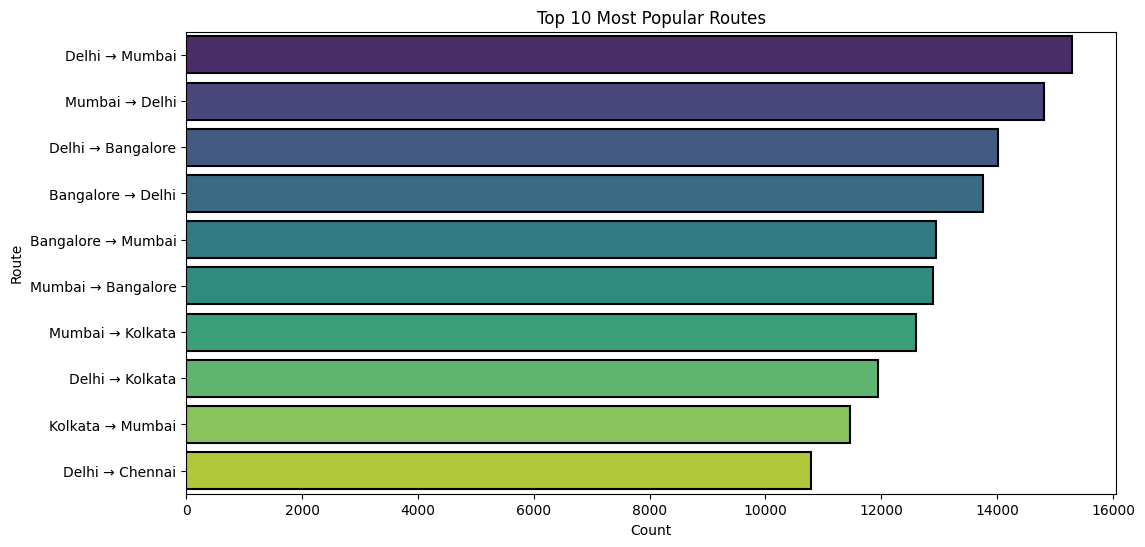

In [173]:
# Visualize source --> destination combinations using the top 10 routes

top_routes = popular_routes.head(10).reset_index(name='count')
top_routes['route'] = top_routes['source_city'] + ' → ' + top_routes['destination_city']
plt.figure(figsize=(12,6))
sns.barplot(x='count', y='route', data=top_routes, palette='viridis', edgecolor='black', linewidth=1.5,color='orange')
plt.title('Top 10 Most Popular Routes')
plt.xlabel('Count')
plt.ylabel('Route')
plt.show()

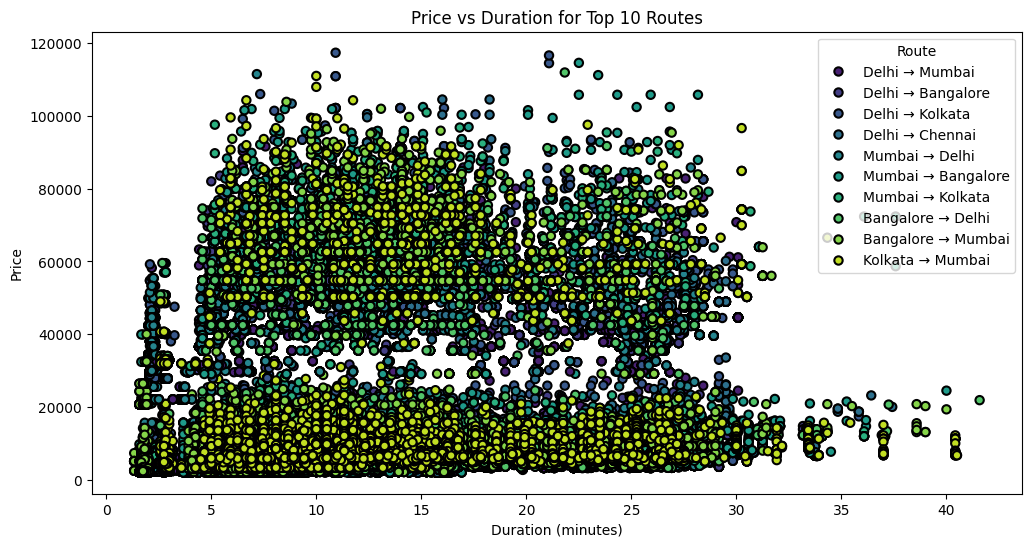

In [174]:
# Price/duration comparison across different routes
top_10_routes = popular_routes.head(10).reset_index(name='count')
top_10_routes['route'] = top_10_routes['source_city'] + ' → ' + top_10_routes['destination_city']
route_price_duration = df.merge(top_10_routes[['source_city', 'destination_city', 'route']], on=['source_city', 'destination_city'], how='inner')
plt.figure(figsize=(12,6))
sns.scatterplot(data=route_price_duration, x='duration', y='price', hue='route', palette='viridis', edgecolor='black', linewidth=1.5)
plt.title('Price vs Duration for Top 10 Routes')
plt.xlabel('Duration (minutes)')
plt.ylabel('Price')
plt.legend(title='Route')
plt.show()

In short: Flight price is not only determined by duration—other factors like route, airline, and class drive big differences. Some routes are highly competitive, while premium segments stand out with very high prices.

In [175]:
# departure time analysis
df['departure_time'].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

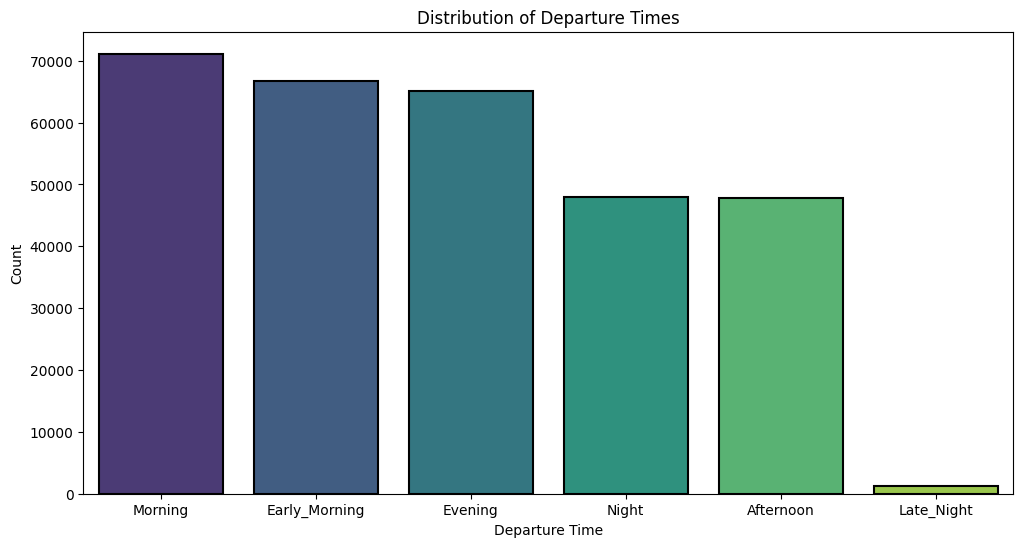

In [176]:
# countplot for departure time
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='departure_time', order=df['departure_time'].value_counts().index, palette='viridis', edgecolor='black', linewidth=1.5,color='cyan')
plt.title('Distribution of Departure Times')
plt.xlabel('Departure Time')
plt.ylabel('Count')
plt.show()


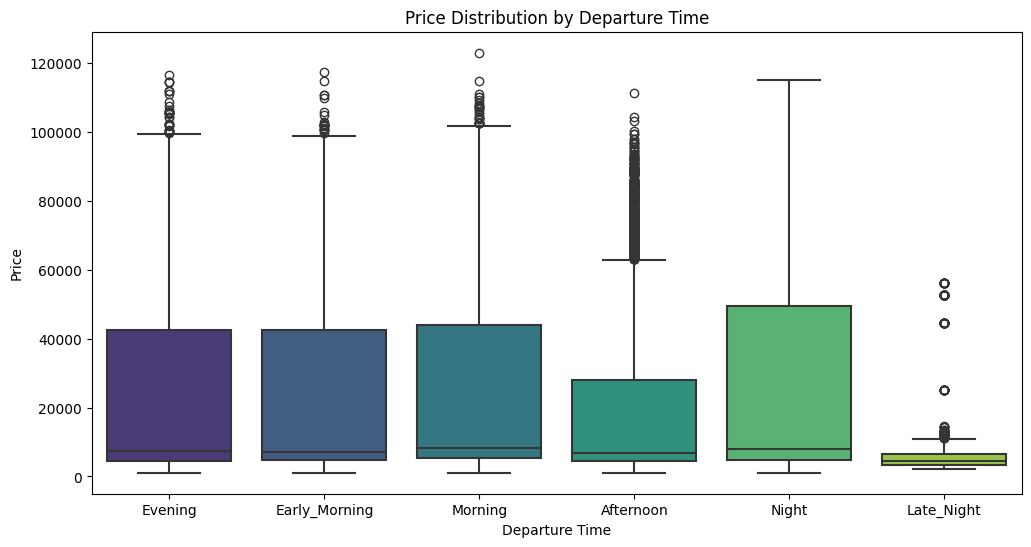

In [177]:
# departure time based price analysis
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='departure_time', y='price', palette='viridis', linewidth=1.5)
plt.title('Price Distribution by Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Price')
plt.show()

This Price Distribution by Departure Time box plot gives you these clear insights:
- Late Night flights → Lowest prices overall, with fewer extreme values. They are the cheapest and most consistent.
- Night flights → Widest price range, including very expensive tickets. This time slot shows the most variation.
- Morning & Afternoon flights → Prices are moderate, with some spread but not as extreme as Night.
- Evening flights → Prices are higher than Late Night but more stable compared to Night.
- Early Morning flights → Prices are also moderate, with fewer outliers compared to Night.

Easy takeaway: Late Night flights are cheapest and stable, while Night flights are the most unpredictable and expensive. Morning, Afternoon, and Evening sit in the middle range.

In [178]:
# Arrival time analysis
df['arrival_time'].value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

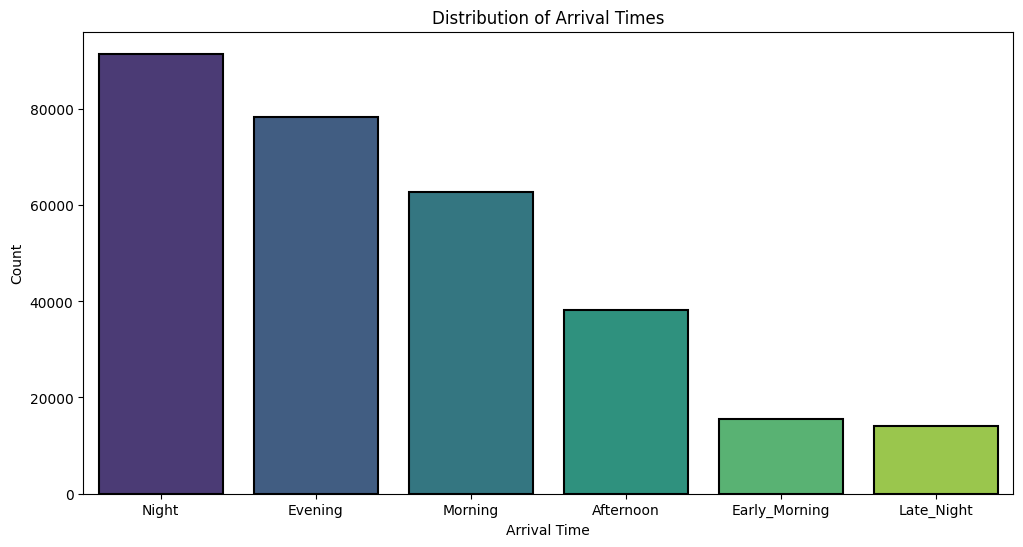

In [179]:
# Visualize arrival time distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='arrival_time', order=df['arrival_time'].value_counts().index, palette='viridis', edgecolor='black', linewidth=1.5,color='magenta')
plt.title('Distribution of Arrival Times')
plt.xlabel('Arrival Time')
plt.ylabel('Count')
plt.show()

In [180]:
# Stops
df['stops'].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

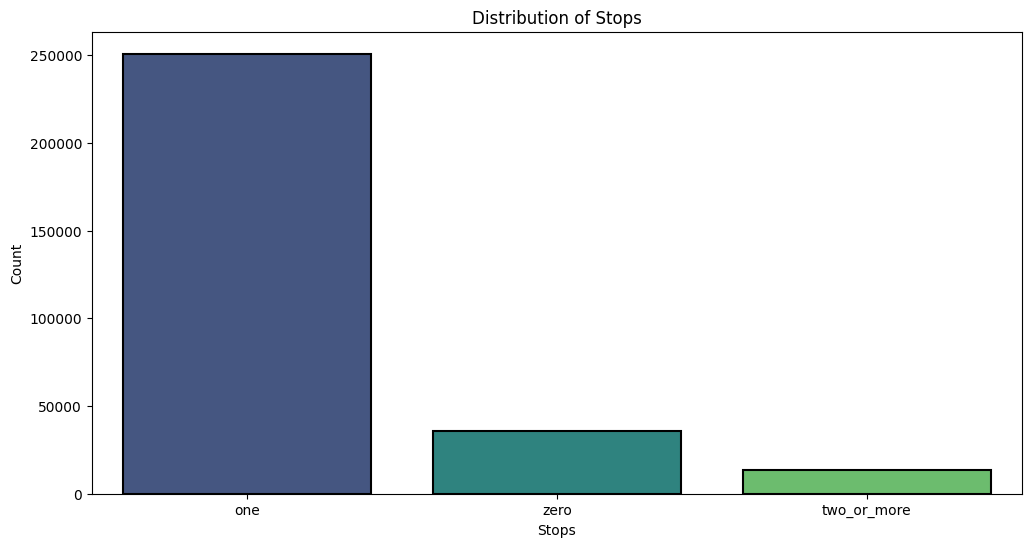

In [181]:
# countplot for stops
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='stops', order=df['stops'].value_counts().index, palette='viridis', edgecolor='black', linewidth=1.5,color='brown')
plt.title('Distribution of Stops')
plt.xlabel('Stops') 
plt.ylabel('Count')
plt.show()

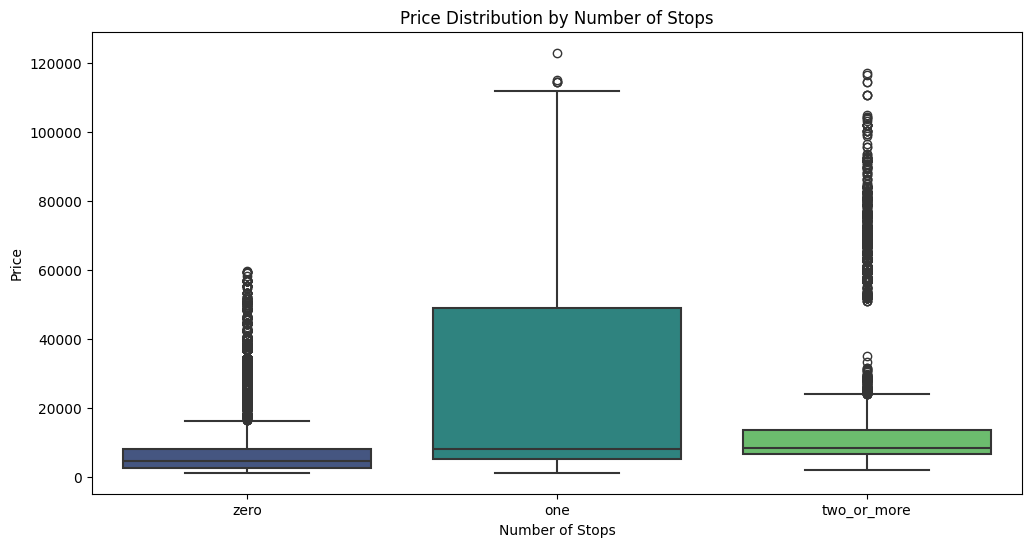

In [182]:
# Price comparison based on number of stops
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='stops', y='price', palette='viridis', linewidth=1.5)
plt.title('Price Distribution by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price')
plt.show()

This Price Distribution by Number of Stops box plot shows these clear insights:
- One stop flights → They are the most expensive overall, with the widest price range. Some tickets even go above 120,000, showing extreme outliers.
- Zero stop flights (non‑stop) → Slightly cheaper on average, with a lower median price compared to others. Prices are more stable.
- Two or more stops → Median price is higher than non‑stop but still lower than one‑stop flights. The spread is narrower, meaning prices are more consistent.

Easy takeaway: One‑stop flights tend to be the costliest and most unpredictable, while non‑stop flights are cheaper and more stable. Multi‑stop flights sit in between but with less variation

In [183]:
# Class
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

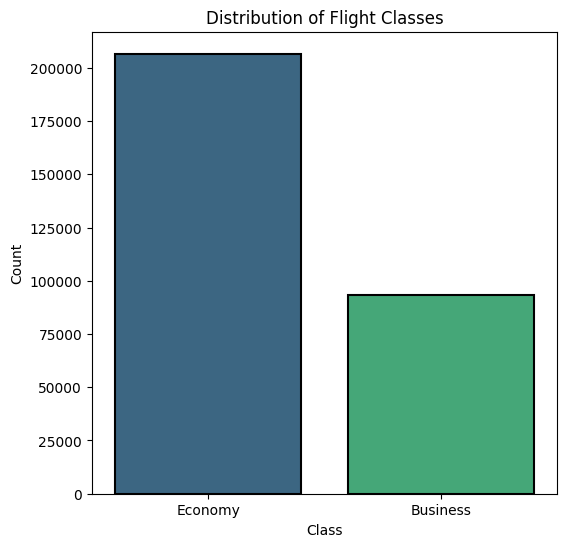

In [184]:
# visualize class distribution
plt.figure(figsize=(6,6))
sns.countplot(data=df, x='class', order=df['class'].value_counts().index, palette='viridis', edgecolor='black', linewidth=1.5,color='magenta')
plt.title('Distribution of Flight Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

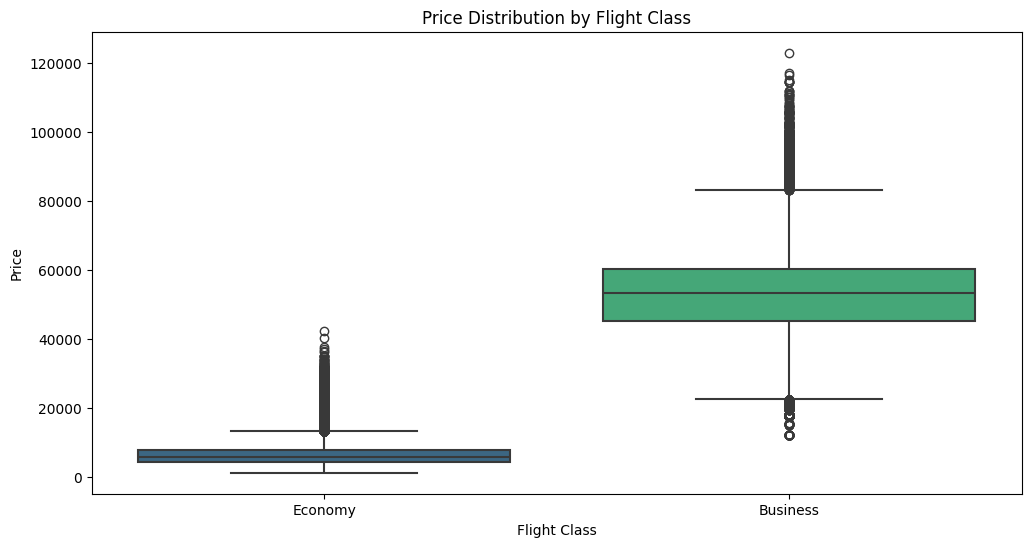

In [185]:
# Price comparison between classes.
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='class', y='price', palette='viridis', linewidth=1.5)
plt.title('Price Distribution by Flight Class')
plt.xlabel('Flight Class')
plt.ylabel('Price')
plt.show()

- Economy class → Prices are generally lower and more consistent. The middle range (most tickets) is tight, meaning you can expect similar prices most of the time.
- Business class → Prices are much higher on average, and they vary a lot. Some tickets go extremely high (above 120,000), showing big outliers.
- Comparison → Economy = cheaper and stable. Business = expensive and unpredictable, with some very premium tickets.

 Easy takeaway: Economy flights are affordable and steady, while Business flights cost much more and can sometimes be extremely expensive.


In [186]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [187]:
# Route Analysis: Which source–destination pairs are most frequent and their average prices.
route_counts = df.groupby(['source_city', 'destination_city']).size()
route_avg_prices = df.groupby(['source_city', 'destination_city'])['price'].mean()    
route_analysis = pd.DataFrame({'count': route_counts, 'avg_price': route_avg_prices}).reset_index()
route_analysis.sort_values(by='count', ascending=False, inplace=True)
print("Most Frequent Routes with Average Prices:")
print(route_analysis.head(10))

Most Frequent Routes with Average Prices:
   source_city destination_city  count     avg_price
14       Delhi           Mumbai  15289  19355.829812
27      Mumbai            Delhi  14809  18725.320008
10       Delhi        Bangalore  14012  17880.216315
1    Bangalore            Delhi  13756  17723.313972
4    Bangalore           Mumbai  12939  23128.618672
25      Mumbai        Bangalore  12885  23147.873807
29      Mumbai          Kolkata  12602  22379.146723
13       Delhi          Kolkata  11934  20566.409418
24     Kolkata           Mumbai  11467  22078.883579
11       Delhi          Chennai  10780  19369.881354


In [188]:
# Airline vs Class: Which airlines operate more business vs economy flights.
airline_class_counts = df.groupby(['airline', 'class'])['price'].mean()
airline_class_counts = airline_class_counts.reset_index(name='price')
print("Airline vs Class Counts:")
print(airline_class_counts)

Airline vs Class Counts:
     airline     class         price
0    AirAsia   Economy   4091.072742
1  Air_India  Business  47131.039212
2  Air_India   Economy   7313.682169
3   GO_FIRST   Economy   5652.007595
4     Indigo   Economy   5324.216303
5   SpiceJet   Economy   6179.278881
6    Vistara  Business  55477.027777
7    Vistara   Economy   7806.943645


In [189]:
# Stops vs Price: Do more stops reduce ticket price or increase duration?

# Grouped summary statistics
summary = df.groupby('stops')[['price','duration']].agg(['mean','median','min','max']).T
print(summary)

stops                      one    two_or_more          zero
price    mean     22900.992482   14113.450775   9375.938535
         median    7959.000000    8307.000000   4499.000000
         min       1105.000000    1966.000000   1105.000000
         max     123071.000000  117307.000000  59573.000000
duration mean        13.496514      15.317141      2.191324
         median      12.250000      12.670000      2.250000
         min          2.920000       3.920000      0.830000
         max         49.830000      49.830000      3.580000


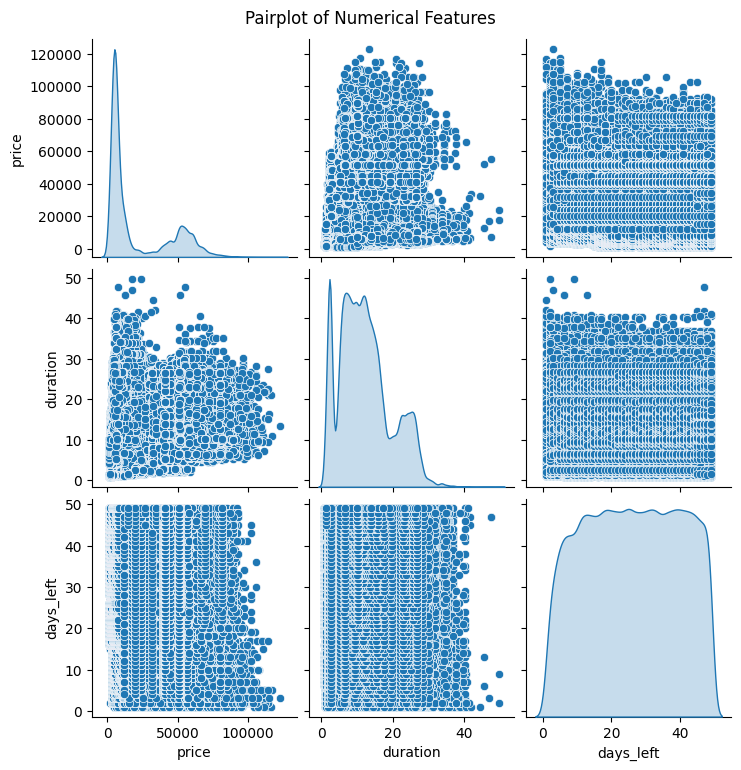

In [190]:
# Visulize the numerical features using pairplot
sns.pairplot(df[['price', 'duration', 'days_left']], diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

- Prices are mostly low but with some very high outliers.
- Durations fall into multiple clusters (short vs long flights).
- Booking days_left doesn’t strongly affect duration or price in this dataset


In [191]:
# Correlation 
correlation_matrix = df[['price', 'duration', 'days_left']].corr()
correlation_matrix

,price,duration,days_left
price,1.000000,0.204222,-0.091949
duration,0.204222,1.000000,-0.039157
days_left,-0.091949,-0.039157,1.000000


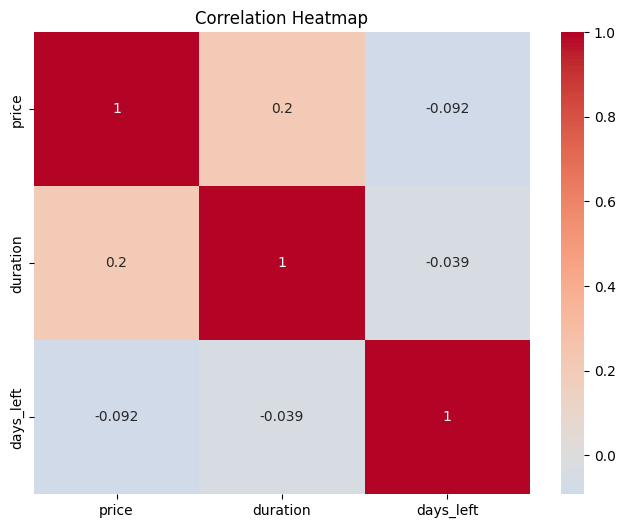

In [192]:
#corrlation heatmap

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

- One-Hot Encoding → airline, source_city, destination_city
- Ordinal Encoding → departure_time, arrival_time, stops
- Label Encoding → class

In [193]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [194]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [195]:
# one-hot encoding for airline, source_city, destination_city
for col in ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time', 'stops', 'class']:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True,dtype=int)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)  


In [196]:
df.head(5)

,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,departure_time_Morning,departure_time_Night,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,stops_two_or_more,stops_zero,class_Economy
0,2.17,1,5953,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,1
1,2.33,1,5953,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,1,1
2,2.17,1,5956,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,1
3,2.25,1,5955,0,0,0,0,1,0,1,...,1,0,0,0,0,0,0,0,1,1
4,2.33,1,5955,0,0,0,0,1,0,1,...,1,0,0,0,0,1,0,0,1,1


In [197]:
df.shape

(300153, 31)

In [198]:
# Separate X and y
X = df.drop(columns=['price'])
y = df[['price']]

In [199]:
X

,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,...,departure_time_Morning,departure_time_Night,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,stops_two_or_more,stops_zero,class_Economy
0,2.17,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,1
1,2.33,1,0,0,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,1,1
2,2.17,1,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1
3,2.25,1,0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,0,0,1,1
4,2.33,1,0,0,0,0,1,0,1,0,...,1,0,0,0,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,10.08,49,0,0,0,0,1,1,0,0,...,1,0,0,1,0,0,0,0,0,0
300149,10.42,49,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
300150,13.83,49,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
300151,10.00,49,0,0,0,0,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0


In [200]:
y

,price
0,5953
1,5953
2,5956
3,5955
4,5955
...,...
300148,69265
300149,77105
300150,79099
300151,81585


In [201]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [202]:
# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regressor - MSE: {mse_rf:.2f}, R2 Score: {r2_rf:.4f}")


Random Forest Regressor - MSE: 7847640.01, R2 Score: 0.9848


In [203]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree Regressor - MSE: {mse_dt:.2f}, R2 Score: {r2_dt:.4f}")


Decision Tree Regressor - MSE: 12493954.60, R2 Score: 0.9758


In [204]:
# extraTrees Regressor
etr = ExtraTreesRegressor(random_state=42)
etr.fit(X_train, y_train)
y_pred_etr = etr.predict(X_test)
mse_etr = mean_squared_error(y_test, y_pred_etr)
r2_etr = r2_score(y_test, y_pred_etr)
print(f"ExtraTrees Regressor - MSE: {mse_etr:.2f}, R2 Score: {r2_etr:.4f}")

ExtraTrees Regressor - MSE: 8824321.58, R2 Score: 0.9829


In [205]:
# Stacking Regressor
estimators = [
    ('rf', RandomForestRegressor(random_state=42)),
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('etr', ExtraTreesRegressor(random_state=42))
]
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stacking_regressor.fit(X_train, y_train)
y_pred_stacking = stacking_regressor.predict(X_test)
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)
print(f"Stacking Regressor - MSE: {mse_stacking:.2f}, R2 Score: {r2_stacking:.4f}")

Stacking Regressor - MSE: 7719144.89, R2 Score: 0.9850


In [206]:
# Voting Regressor
voting_regressor = VotingRegressor(estimators=estimators)
voting_regressor.fit(X_train, y_train)
y_pred_voting = voting_regressor.predict(X_test)
mse_voting = mean_squared_error(y_test, y_pred_voting)
r2_voting = r2_score(y_test, y_pred_voting)
print(f"Voting Regressor - MSE: {mse_voting:.2f}, R2 Score: {r2_voting:.4f}")


Voting Regressor - MSE: 8564488.70, R2 Score: 0.9834


In [209]:
# Hyper parameter tuning for Random Forest Regressor
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)
print("Best Hyperparameters for Random Forest Regressor:")
print(grid_search_rf.best_params_)
print(f"Best Cross-Validation R2 Score: {grid_search_rf.best_score_:.2f}")
print(f"Test Set R2 Score with Best Hyperparameters: {grid_search_rf.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Hyperparameters for Random Forest Regressor:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation R2 Score: 0.99
Test Set R2 Score with Best Hyperparameters: 0.9858


In [210]:
# Now, we can retrain the Random Forest Regressor with the best hyperparameters and evaluate it on the test set.
best_rf = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_best_rf = best_rf.predict(X_test)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)
print(f"Best Random Forest Regressor - MSE: {mse_best_rf:.2f}, R2 Score: {r2_best_rf:.4f}")


Best Random Forest Regressor - MSE: 7296011.48, R2 Score: 0.9858
